# Solving an RBC Model with Sequence-Space Jacobians in Julia

- Authors: Yuxuan Zhao
- Date: 2026-06-06


This notebook solves a simple RBC model using a minimal sequence-space Jacobian (SSJ) method written from scratch in Julia. The notebook is structured as follows:

1. Model and SSJ algorithm.
2. Julia implementation of the RBC blocks.
3. Construction of $H_U$, $H_Z$, and the general-equilibrium Jacobian.
4. Impulse responses to regular and news TFP shocks.


## 1) Model

### RBC model

Time is discrete and the economy is populated by a representative household and a representative competitive firm. 

The only exogenous aggregate object is the TFP path $\{Z_t\}_{t=0}^{T-1}$. The path of TFP is predetermined at time 0, household and firm perfectly foresee the entire TFP path.

The economy starts in a steady state at time $-1$, and experiences a transition path from time 0 to $T-1$ in response to a TFP disturbance. At time $T$, we impose that the economy returns to the steady state.

The perfect foresight competitive equilibrium consists of  prices $\{r_t,w_t\}_{t=0}^{T-1}$, quantities $\{C_t,I_t,A_{t+1},L_t,Y_t\}_{t=0}^{T-1}$, firm's production plan $\{K^f_t,L^f_t\}_{t=0}^{T-1}$ such that:

### Imposed transition path

We impose that for $t \geq T$, the economy returns to the steady state, thus for all $t \geq T$:

$C_t=C_{ss}$, $L_t=L_{ss}$, $A_t=K_{ss}$, $r_t=r_{ss}$, and $w_t=w_{ss}$

### Household problem

Given prices $\{r_t,w_t\}_{t=0}^{T-1}$ and imposed transition path condition, the representative household chooses paths $\{C_t,L_t,A_{t+1}\}_{t=0}^{T-1}$ to maximize lifetime utility

$$
\sum_{t=0}^{\infty} \beta^t \left[\frac{C_t^{1-1/\psi}}{1-1/\psi} - \varphi \frac{L_t^{1+1/\nu}}{1+1/\nu}\right],
$$

subject to the period budget constraint

$$
\begin{aligned}
C_t + A_{t+1} &= (1+r_t)A_{t} + w_t L_t, \\
A_{t+1} &\geq - \bar A, \\
C_t &\geq 0, \quad L_t \in [0,1]. \\
\end{aligned}
$$


### Firm problem

Given prices $\{r_t,w_t\}_{t=0}^{T-1}$, the representative firm chooses paths $\{K^f_t,L^f_t\}_{t=0}^{T-1}$ to maximize profits, for $t=0,\ldots,T-1$:

$$
\max \left[Z_t (K^f_{t})^\alpha (L^f_t)^{1-\alpha} - (r_t+\delta) K^f_{t} - w_t L^f_t\right].
$$

which implies the first-order conditions:

$$
\begin{aligned}
r_t + \delta &= \alpha Z_t \left(\frac{K_t}{L_t}\right)^{\alpha-1}, \\
w_t &= (1-\alpha) Z_t \left(\frac{K_t}{L_t}\right)^\alpha.
\end{aligned}
$$

### Market clearing and capital accumulation

Investment is defined by the law of motion for capital:

$$
I_t = K^f_{t+1} - (1-\delta)K^f_{t}.
$$

Market clears for time $t=0,\ldots,T-1$:

$$
\begin{aligned}
Y_t &= C_t + I_t \\
K^f_t &= A_{t} \\
L^f_t &= L_t.
\end{aligned}
$$

### Summary of equilibrium conditions

Define $K_t = A_t = K^f_t, \quad L_t = L^f_t$ for simplicity, so we can ignore capital and labor market clearing conditions.

For computation, we can write the model as residual equations:

$$
\begin{aligned}
0 &= C_t^{-1/\psi} - \beta (1+r_{t+1}) C_{t+1}^{-1/\psi}, \\
0 &= w_t - \varphi L_t^{1/\nu} C_t^{1/\psi}, \\
0 &= K_{t+1} - (1-\delta)K_{t} - I_t, \\
0 &= r_t + \delta - \alpha Z_t \left(\frac{K_{t}}{L_t}\right)^{\alpha-1}, \\
0 &= w_t - (1-\alpha) Z_t \left(\frac{K_{t}}{L_t}\right)^\alpha, \\
0 &= Y_t - Z_t K_{t}^\alpha L_t^{1-\alpha}, \\
0 &= Y_t - C_t - I_t.
\end{aligned}
$$



## 2) Sequence-space representation

The state-space approach asks: given the current state, how does the economy transition next period? The sequence-space approach asks a different question: given an entire path of shocks, what entire path of endogenous variables clears all equilibrium conditions?

For the RBC model, collect the endogenous paths in $X=\{C,I,K,L,Y,r,w\}$ and the exogenous TFP path in $Z=\{Z_t\}_{t=0}^{T-1}$. Equilibrium can be written as a system of residual equations over time:

$$
F(X,Z)=0.
$$

The SSJ idea is to solve the local dynamics around the steady state by differentiating this sequence-space system.

### DAG representation for the RBC model

We use the same DAG idea as in the Python SSJ tutorial. Rather than treating all variables as unknowns, we choose a small set of unknown paths and target equations:

$$
U=\{K,L\}, \qquad H=\{\text{Euler residual},\text{goods market residual}\}, \qquad Z=\{Z\}.
$$

Given paths for $K$, $L$, and $Z$, the blocks compute the remaining variables:

1. Firm block: $(K,L,Z) \mapsto (r,w,Y)$.
2. Household block: $(K,L,w) \mapsto (C,I)$.
3. Market-clearing block: $(r,C,Y,I,K,L,w) \mapsto (\text{Euler},\text{goods market})$.

Thus the reduced equilibrium system is

$$
H(U,Z)=0.
$$

### Local linearization

Around the steady state, a first-order approximation gives

$$
H_U dU + H_Z dZ = 0,
$$

where $H_U$ is the Jacobian of the target residuals with respect to the unknown paths, and $H_Z$ is the Jacobian of the target residuals with respect to the exogenous shock path. Solving this linear system gives the general-equilibrium response of the unknown paths:

$$
G_{U,Z} = \frac{dU}{dZ} = -H_U^{-1}H_Z.
$$

After $G_{U,Z}$ is known, we feed the implied $K$ and $L$ paths back through the blocks to recover the response of any other variable, such as $C$, $Y$, $r$, or $w$. This is the second forward accumulation step: once the unknowns respond correctly, all other variables follow from the model blocks.

### Numerical algorithm used below

This notebook implements the following simple version of the SSJ method:

1. Compute the steady state analytically.
2. Define Julia functions for the firm, household, and market-clearing blocks.
3. Construct the residual map $H(U,Z)$ over a finite horizon $T$.
4. Compute $H_U$ and $H_Z$ by finite differences.
5. Solve $U_Z=-H_U^{-1}H_Z$.
6. Build variable-level Jacobians such as $G^{C,Z}$.
7. Multiply these Jacobians by shock paths to obtain impulse responses.

The finite-difference implementation is not the fastest way to compute SSJ matrices, but it makes the mechanics transparent for this RBC example.

---

# Code Implementation in Julia

## 1) Calibration and Steady State

We take structural parameters and steady-state technology as primitives. In particular, we use

$$
\alpha=0.11,\qquad \delta=0.025,\qquad \beta=0.99,
$$

$$
\psi=1,\qquad \nu=1,\qquad \varphi=1,\qquad Z_{ss}=1.
$$

Here $\psi$ is the intertemporal elasticity of substitution and $\nu$ is the Frisch elasticity. We do not normalize $Y_{ss}=1$, and we do not back out $\beta$ or $\varphi$ from steady-state targets.

At the steady state, all variables are constant over time. The steady-state equilibrium conditions are

$$
\begin{aligned}
0 &= C_{ss}^{-1/\psi} - \beta(1+r_{ss})C_{ss}^{-1/\psi}, \\
0 &= w_{ss} - \varphi L_{ss}^{1/\nu}C_{ss}^{1/\psi}, \\
0 &= I_{ss}-\delta K_{ss}, \\
0 &= r_{ss}+\delta - \alpha Z_{ss}\left(\frac{K_{ss}}{L_{ss}}\right)^{\alpha-1}, \\
0 &= w_{ss}-(1-\alpha)Z_{ss}\left(\frac{K_{ss}}{L_{ss}}\right)^\alpha, \\
0 &= Y_{ss}-Z_{ss}K_{ss}^\alpha L_{ss}^{1-\alpha}, \\
0 &= Y_{ss}-C_{ss}-I_{ss}.
\end{aligned}
$$

The unknown steady-state vector is

$$
x_{ss}=(K_{ss},L_{ss},C_{ss},I_{ss},Y_{ss},r_{ss},w_{ss}).
$$

Below we solve this nonlinear system using Newton's method starting from an initial guess. This is overkill for this simple RBC steady state, which can be solved analytically, but it makes the computational step explicit and mirrors the way more complicated models are usually solved.

In [46]:
using LinearAlgebra
include("SSJ_Function.jl")

# Store structural parameters. These are primitives, not steady-state targets.
Base.@kwdef struct Params
    alpha::Float64 = 0.11
    delta::Float64 = 0.025
    beta::Float64 = 0.99
    eis::Float64 = 1.0
    frisch::Float64 = 1.0
    vphi::Float64 = 1.0
    Zss::Float64 = 1.0
end

# Store steady-state objects that will be used as boundary values.
struct SteadyState
    K::Float64
    L::Float64
    Z::Float64
    Y::Float64
    C::Float64
    I::Float64
    r::Float64
    w::Float64
end

# Steady-state residuals for x = (K, L, C, I, Y, r, w).
function steady_state_residual(x, params::Params)
    K, L, C, I, Y, r, w = x

    return [
        C^(-1 / params.eis) - params.beta * (1 + r) * C^(-1 / params.eis),
        w - params.vphi * L^(1 / params.frisch) * C^(1 / params.eis),
        I - params.delta * K,
        r + params.delta - params.alpha * params.Zss * (K / L)^(params.alpha - 1),
        w - (1 - params.alpha) * params.Zss * (K / L)^params.alpha,
        Y - params.Zss * K^params.alpha * L^(1 - params.alpha),
        Y - C - I
    ]
end

function compute_steady_state(params::Params)
    x0 = [3.5, 1.0, 1.0, 0.1, 1.1, 0.01, 1.0]
    is_positive = x -> all(x[[1, 2, 3, 4, 5, 7]] .> 0)
    x = newton_solve(x -> steady_state_residual(x, params), x0; is_valid=is_positive)
    K, L, C, I, Y, r, w = x
    return SteadyState(K, L, params.Zss, Y, C, I, r, w)
end

# Compute and display the calibration used throughout the notebook.
params = Params()
ss = compute_steady_state(params)

println("K = ", ss.K)
println("L = ", ss.L)
println("Z = ", ss.Z)
println("Y = ", ss.Y)
println("C = ", ss.C)
println("I = ", ss.I)
println("r = ", ss.r)
println("w = ", ss.w)
println("beta = ", params.beta)
println("vphi = ", params.vphi)

K = 3.5464705736103728
L = 0.9826772184449017
Z = 1.0
Y = 1.131679085702121
C = 1.0430173213618619
I = 0.08866176434025932
r = 0.010101010101010202
w = 1.0249493601457205
beta = 0.99
vphi = 1.0


## 2) RBC Blocks and DAG

The next step is to define the DAG used by the sequence-space calculation. The DAG works with finite sequences for dates $t=0,\ldots,T-1$. The initial capital stock $K_0$ is predetermined and fixed at $K_{ss}$, while the capital choices inside the unknown vector are $K_1,\ldots,K_T$.

### Exogenous input, unknowns, and targets

The exogenous input is the TFP sequence:

$$
Z=(Z_0,Z_1,\ldots,Z_{T-1}).
$$

The unknown sequence is

$$
U=(K_1,\ldots,K_T,L_0,\ldots,L_{T-1}).
$$

The target residuals are the Euler equation and goods market clearing:

$$
H=\{\text{euler},\text{goods\_mkt}\}.
$$

The first $T$ entries are the capital choices made over dates $0,\ldots,T-1$. The last $T$ entries are labor choices over the same dates. These are level values, not deviations from steady state.

The target residual sequence is

$$
H(U,Z)=(\text{euler}_0,\ldots,\text{euler}_{T-1},\text{goods\_mkt}_0,\ldots,\text{goods\_mkt}_{T-1}).
$$

The SSJ problem is to find the unknown sequence $U$ such that all $2T$ target residuals are zero for a given TFP sequence $Z$.

### Blocks in the DAG

We use three economic blocks. Each block takes full sequences as inputs and returns full sequences as outputs.

1. **Firm block**

   Sequence inputs:

   $$
   K^{\text{prod}}=(K_0,K_1,\ldots,K_{T-1}),\qquad L=(L_0,\ldots,L_{T-1}),\qquad Z=(Z_0,\ldots,Z_{T-1}).
   $$

   The production capital sequence is constructed from the unknown capital-choice sequence by

   $$
   K^{\text{prod}}=(K_{ss},K_1,\ldots,K_{T-1}),
   $$

   using the initial condition $K_0=K_{ss}$.

   Sequence outputs:

   $$
   r=(r_0,\ldots,r_{T-1}),\qquad w=(w_0,\ldots,w_{T-1}),\qquad Y=(Y_0,\ldots,Y_{T-1}).
   $$

   The block computes factor prices and output:

   $$
   r_t=\alpha Z_t\left(\frac{K_t^{\text{prod}}}{L_t}\right)^{\alpha-1}-\delta,
   \qquad
   w_t=(1-\alpha)Z_t\left(\frac{K_t^{\text{prod}}}{L_t}\right)^\alpha,
   $$

   $$
   Y_t=Z_t(K_t^{\text{prod}})^\alpha L_t^{1-\alpha}, \qquad t=0,\ldots,T-1.
   $$

2. **Household block**

   Sequence inputs:

   $$
   K^+=(K_1,\ldots,K_T),\qquad L=(L_0,\ldots,L_{T-1}),\qquad w=(w_0,\ldots,w_{T-1}).
   $$

   Sequence outputs:

   $$
   C=(C_0,\ldots,C_{T-1}),\qquad I=(I_0,\ldots,I_{T-1}).
   $$

   The block uses the labor supply condition to recover consumption and uses capital accumulation to compute investment:

   $$
   C_t=\left(\frac{w_t}{\varphi L_t^{1/\nu}}\right)^\psi,
   \qquad
   I_t=K_{t+1}-(1-\delta)K_t, \qquad t=0,\ldots,T-1.
   $$

3. **Market-clearing block**

   Sequence inputs:

   $$
   r,C,Y,I,K^+,L,w.
   $$

   Sequence outputs:

   $$
   \text{goods\_mkt}=(\text{goods\_mkt}_0,\ldots,\text{goods\_mkt}_{T-1}),
   $$

   $$
   \text{euler}=(\text{euler}_0,\ldots,\text{euler}_{T-1}),
   $$

   and a diagnostic sequence $\text{walras}=(\text{walras}_0,\ldots,\text{walras}_{T-1})$.

   The target residuals are

   $$
   \text{goods\_mkt}_t=Y_t-C_t-I_t,
   $$

   $$
   \text{euler}_t=C_t^{-1/\psi}-\beta(1+r_{t+1})C_{t+1}^{-1/\psi}, \qquad t=0,\ldots,T-1.
   $$

   For the final Euler equation, the lead values are closed with the terminal steady state: $C_T=C_{ss}$ and $r_T=r_{ss}$. The `walras` residual is reported as a diagnostic but is not used as a target.


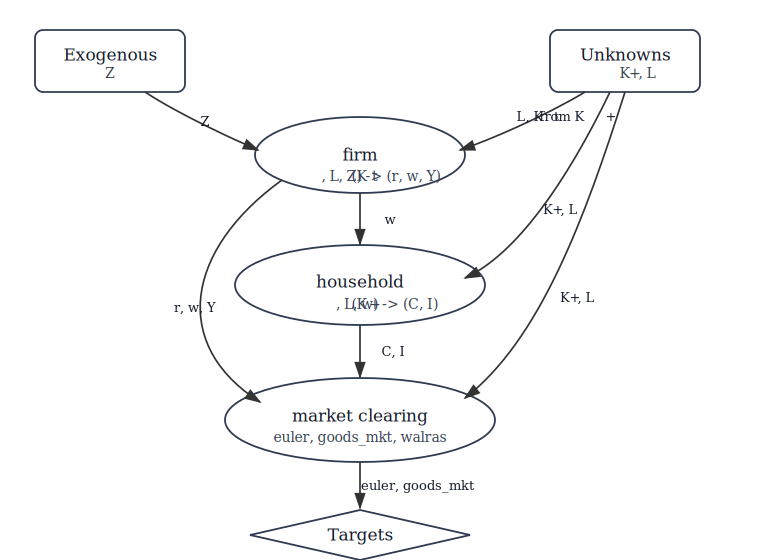

In [47]:
# Draw the RBC DAG defined in SSJ_Function.jl.
display(InlineSVG(rbc_dag_svg()))

In [48]:
# Here K stores next-period capital K_{t+1}. This lag gives current capital K_t.
lag(x, xss) = vcat(xss, x[1:end-1])

# For forward-looking variables: x(+1), with steady state after T-1.
lead(x, xss) = vcat(x[2:end], xss)

# Firm block: use current capital K_t, labor L_t, and TFP Z_t to compute prices and output.
function firm(K, L, Z, ss, params)
    Kcurrent = lag(K, ss.K)
    r = params.alpha .* Z .* (Kcurrent ./ L).^(params.alpha - 1) .- params.delta
    w = (1 - params.alpha) .* Z .* (Kcurrent ./ L).^params.alpha
    Y = Z .* Kcurrent.^params.alpha .* L.^(1 - params.alpha)
    return r, w, Y
end

# Household block: compute consumption from labor supply and investment from K_{t+1} - (1-delta)K_t.
function household(K, L, w, ss, params)
    Kcurrent = lag(K, ss.K)
    C = (w ./ params.vphi ./ L.^(1 / params.frisch)).^params.eis
    I = K .- (1 - params.delta) .* Kcurrent
    return C, I
end

# Market-clearing block: return residuals of equilibrium conditions.
function market_clearing(r, C, Y, I, K, L, w, ss, params)
    rlead = lead(r, ss.r)
    Clead = lead(C, ss.C)
    goods_mkt = Y .- C .- I
    euler = C.^(-1 / params.eis) .- params.beta .* (1 .+ rlead) .* Clead.^(-1 / params.eis)
    walras = C .+ K .- (1 .+ r) .* lag(K, ss.K) .- w .* L
    return goods_mkt, euler, walras
end

# Full DAG evaluation: run firm -> household -> market clearing.
function evaluate_model(K, L, Z, ss, params)
    r, w, Y = firm(K, L, Z, ss, params)
    C, I = household(K, L, w, ss, params)
    goods_mkt, euler, walras = market_clearing(r, C, Y, I, K, L, w, ss, params)
    return (; r, w, Y, C, I, goods_mkt, euler, walras)
end

evaluate_model (generic function with 1 method)

## 3) Sequence-Space Residual Map

The dynamic unknowns are the same level sequences defined above. For the Jacobian step below, we stack them into one vector,

$$
    U = (K_1,\ldots,K_T,L_0,\ldots,L_{T-1}),
$$

Here $U$ is written in levels, not deviations from steady state.

The exogenous input is the level TFP sequence $Z=(Z_0,\ldots,Z_{T-1})$. The function `H(K, L, Z, ss, params)` does the following:

1. Take the level paths $K^+$, $L$, and $Z$ as inputs.
2. Run the firm and household blocks to compute $r,w,Y,C,I$.
3. Run the market-clearing block to compute the Euler residual and goods-market residual.
4. Stack those two residual vectors into one vector.

Thus the residual map is

$$
    H(U,Z) =
    \begin{pmatrix}
    \text{euler}_0 \\
    \vdots \\
    \text{euler}_{T-1} \\
    \text{goods\_mkt}_0 \\
    \vdots \\
    \text{goods\_mkt}_{T-1}
    \end{pmatrix}.
$$

At the steady state, $K^+=(K_{ss},\ldots,K_{ss})$, $L=(L_{ss},\ldots,L_{ss})$, and $Z=(Z_{ss},\ldots,Z_{ss})$, so the maximum absolute residual should be essentially zero.

In [49]:
# H(K, L, Z) stacks the target residuals used to solve equilibrium.
function H(K, L, Z, ss, params)
    # Evaluate the DAG and keep only the target equations.
    out = evaluate_model(K, L, Z, ss, params)
    return vcat(out.euler, out.goods_mkt)
end

function unpack_U(U, T)
    K = U[1:T]
    L = U[T+1:2T]
    return K, L
end

T = 80
K_ss_path = fill(ss.K, T)
L_ss_path = fill(ss.L, T)
Z_ss_path = fill(ss.Z, T)

steady_residual = H(K_ss_path, L_ss_path, Z_ss_path, ss, params)
println("Maximum steady-state residual: ", maximum(abs.(steady_residual)))

Maximum steady-state residual: 3.774758283725532e-15


## 4) Compute $H_U$, $H_Z$, and $U_Z$

This is the central SSJ step. We give a small perturbation to the TFP path:
$$
Z = Z_{ss}+dZ
$$
then we compute the response of the unknown variables $U$, because this is a small perturbation to the TFP path, the response of $U$ is also a small perturbation, denoted by:
$$
U = U_{ss} + dU.
$$

Around the steady state, the residual map can be approximated by a first-order Taylor expansion:

$$
H(U_{ss}+dU,Z_{ss}+dZ) \approx H(U_{ss},Z_{ss}) + H_U dU + H_Z dZ.
$$

Since $H(U_{ss},Z_{ss})=0$ at the steady state, the linearized equilibrium condition is

$$
H_U dU + H_Z dZ = 0.
$$

Here $H_U$ is the Jacobian of target residuals with respect to the unknown paths $U=(K^+,L)$, while $H_Z$ is the Jacobian of target residuals with respect to the TFP path $Z$.

With two targets and two unknown paths over $T$ periods, the dimensions are

$$
H_U: (2T)\times(2T), \qquad H_Z: (2T)\times T.
$$

The code computes these matrices by finite differences. For a generic function $f(x)$, the $j$-th column of the Jacobian is approximated by

$$
    \frac{f(x+h e_j)-f(x)}{h}.
$$

After obtaining $H_U$ and $H_Z$, solve the linear system for the response of unknowns to shocks:

$$
    U_Z = \frac{dU}{dZ} = -H_U^{-1}H_Z.
$$

In Julia, `-H_U \ H_Z` solves this system without explicitly computing the matrix inverse.

In [50]:
# Build H_U, H_Z, and solve for U_Z = -H_U^{-1}H_Z.
function solve_ssj_jacobians(ss, params; T=80)
    Uss = vcat(fill(ss.K, T), fill(ss.L, T))
    Zss = fill(ss.Z, T)

    H_stacked = function(U, Z)
        K, L = unpack_U(U, T)
        return H(K, L, Z, ss, params)
    end

    # Targets with respect to unknown paths U=(K^+, L).
    H_U = finite_difference_jacobian_at(U -> H_stacked(U, Zss), Uss; h=1e-5)

    # Targets with respect to the exogenous TFP path Z.
    H_Z = finite_difference_jacobian_at(Z -> H_stacked(Uss, Z), Zss; h=1e-5)

    # Julia's \ solves the linear system without forming inv(H_U).
    U_Z = -H_U \ H_Z
    return H_U, H_Z, U_Z
end

H_U, H_Z, U_Z = solve_ssj_jacobians(ss, params; T=T)

println("size(H_U) = ", size(H_U))
println("size(H_Z) = ", size(H_Z))
println("size(U_Z) = ", size(U_Z))

size(H_U) = (160, 160)
size(H_Z) = (160, 80)
size(U_Z) = (160, 80)


## 5) Recover General-Equilibrium Jacobians for Model Variables

`U_Z` only tells us how the unknown sequence responds to a TFP shock. Given a shock sequence $dZ$, it gives

$$
dU=U_ZdZ,
$$

where $dU$ contains the responses of $K^+=(K_1,\ldots,K_T)$ and $L=(L_0,\ldots,L_{T-1})$.

To recover the response of any other variable, we convert the unknown response back into level paths,

$$
U=U_{ss}+dU, \qquad Z=Z_{ss}+dZ,
$$

and then evaluate the RBC blocks again in DAG order:

$$
\text{firm block:}\qquad (K,L,Z) \rightarrow (r,w,Y),
$$

$$
\text{household block:}\qquad (K,L,w) \rightarrow (C,I),
$$

$$
\text{market-clearing block:}\qquad (r,C,Y,I,K,L,w) \rightarrow (\text{euler},\text{goods\_mkt},\text{walras}).
$$

For recovering variables such as $C$, $Y$, $r$, $w$, and $I$, the first two blocks are enough. The market-clearing block is useful for checking that the recovered paths indeed make the target residuals equal to zero.

For a generic variable $X=X(U,Z)$, the general-equilibrium Jacobian follows from the chain rule:

$$
G^{X,Z}=\frac{dX}{dZ}=X_U U_Z + X_Z.
$$

Here $X_U$ is the partial Jacobian of $X$ with respect to the unknown sequence, holding $Z$ fixed, and $X_Z$ is the partial Jacobian of $X$ with respect to TFP, holding $U$ fixed. The function `variable_jacobian` computes $X_U$ and $X_Z$ by finite differences around the steady state, then combines them with `U_Z` using this formula.

This builds matrices such as

$$
G^{C,Z}=\frac{dC}{dZ}, \qquad G^{Y,Z}=\frac{dY}{dZ}, \qquad G^{L,Z}=\frac{dL}{dZ}.
$$

For example, column $j$ of $G^{C,Z}$ is the full consumption response to a small TFP shock at date $j$.

In [51]:
# Evaluate one model variable in levels for given level paths U and Z.
function variable_levels(varname, U, Z, ss, params)
    T = length(Z)
    K, L = unpack_U(U, T)
    out = evaluate_model(K, L, Z, ss, params)
    values = varname == :K ? K :
             varname == :L ? L :
             varname == :Z ? Z :
             getproperty(out, varname)
    return values
end

# Build G^{var,Z} using the chain rule: G = var_U * U_Z + var_Z.
function variable_jacobian(varname, U_Z, ss, params; T=80, h=1e-5)
    Uss = vcat(fill(ss.K, T), fill(ss.L, T))
    Zss = fill(ss.Z, T)

    var_U = finite_difference_jacobian_at(U -> variable_levels(varname, U, Zss, ss, params), Uss; h=h)
    var_Z = finite_difference_jacobian_at(Z -> variable_levels(varname, Uss, Z, ss, params), Zss; h=h)

    return var_U * U_Z + var_Z
end

G_CZ = variable_jacobian(:C, U_Z, ss, params; T=T)
G_YZ = variable_jacobian(:Y, U_Z, ss, params; T=T)
G_KZ = variable_jacobian(:K, U_Z, ss, params; T=T)
G_LZ = variable_jacobian(:L, U_Z, ss, params; T=T)

println("size(G_CZ) = ", size(G_CZ))

size(G_CZ) = (80, 80)


## 6) Impulse Responses and Plots

Once $G^{C,Z}$ is known, any small TFP shock path can be mapped into a consumption response by matrix multiplication:

$$
    dC = G^{C,Z} dZ.
$$

The same logic applies to output, capital, labor, and other variables.

We consider three experiments. Let the impact size be $\varepsilon=0.01$, the persistence be $\rho=0.8$, and the delay be $N=10$.

1. **Regular TFP shock**. TFP rises on impact and then decays:

$$
dZ_t^{\text{regular}}=\varepsilon Z_{ss}\rho^t, \qquad t=0,\ldots,T-1.
$$

2. **News shock**. Agents learn at date 0 that TFP will rise only at date $N$:

$$
dZ_t^{\text{news}}=
\begin{cases}
0, & t<N, \\
\varepsilon Z_{ss}\rho^{t-N}, & t\geq N.
\end{cases}
$$

Because agents know the whole future path at date 0, variables may respond before date $N$.

3. **Surprise shock at date $N$**. The realized TFP path is the same as the news shock, but agents do not know about it before date $N$. Therefore the economy stays at steady state before date $N$, and from date $N$ onward the response is the regular impact response shifted forward by $N$ periods.

The important point is that once the Jacobian has been computed, changing the anticipated shock path does not require solving the model again. We only multiply the already-computed response matrix by a new shock vector.

In [52]:
# Shock parameters.
impact = 0.01
rho = 0.8
news = 10

# Regular shock: TFP rises on impact and then decays.
dZ_regular = impact * ss.Z .* (rho .^ (0:T-1))

# News shock: the same shock is announced today but arrives after `news` periods.
dZ_news = vcat(zeros(news), dZ_regular[1:T-news])

# Surprise shock at date `news`: same realized TFP path, but no anticipation before then.
dZ_surprise = copy(dZ_news)

# Convert level responses into percent deviations from steady state.
dC_regular = 100 .* (G_CZ * dZ_regular) ./ ss.C
dC_news = 100 .* (G_CZ * dZ_news) ./ ss.C
dC_surprise = vcat(zeros(news), dC_regular[1:T-news])

dY_regular = 100 .* (G_YZ * dZ_regular) ./ ss.Y
dK_regular = 100 .* (G_KZ * dZ_regular) ./ ss.K
dL_regular = 100 .* (G_LZ * dZ_regular) ./ ss.L

println("First 12 consumption responses to regular TFP shock, percent deviations:")
println(round.(dC_regular[1:12], digits=4))

println("\nFirst 15 consumption responses to news TFP shock, percent deviations:")
println(round.(dC_news[1:15], digits=4))

println("\nFirst 15 consumption responses to surprise TFP shock at date 10, percent deviations:")
println(round.(dC_surprise[1:15], digits=4))

First 12 consumption responses to regular TFP shock, percent deviations:
[0.3704, 0.3991, 0.4103, 0.4089, 0.3985, 0.3822, 0.3618, 0.3392, 0.3154, 0.2913, 0.2677, 0.2448]

First 15 consumption responses to news TFP shock, percent deviations:
[0.0835, 0.0825, 0.0828, 0.0844, 0.0874, 0.0918, 0.0977, 0.1052, 0.1144, 0.1256, 0.1999, 0.2479, 0.2763, 0.2902, 0.2934]

First 15 consumption responses to surprise TFP shock at date 10, percent deviations:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3704, 0.3991, 0.4103, 0.4089, 0.3985]


The plot below uses `Plots.jl`. The left panel shows the TFP shock paths. The news and surprise experiments have the same realized TFP path, but different information timing. The right panel shows the implied consumption responses.

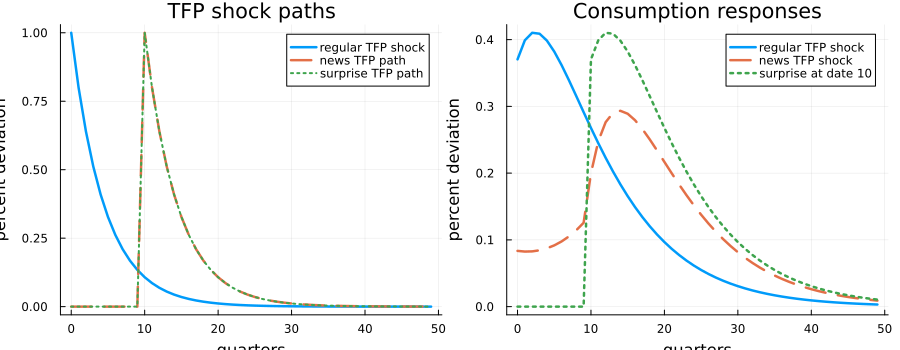

In [53]:
using Plots

plot_horizon = 50
quarters = 0:plot_horizon-1

shock_plot = plot(
    quarters,
    100 .* dZ_regular[1:plot_horizon] ./ ss.Z,
    label="regular TFP shock",
    linewidth=2.5,
    xlabel="quarters",
    ylabel="percent deviation",
    title="TFP shock paths"
)
plot!(
    shock_plot,
    quarters,
    100 .* dZ_news[1:plot_horizon] ./ ss.Z,
    label="news TFP path",
    linewidth=2.5,
    linestyle=:dash
)
plot!(
    shock_plot,
    quarters,
    100 .* dZ_surprise[1:plot_horizon] ./ ss.Z,
    label="surprise TFP path",
    linewidth=2.0,
    linestyle=:dot
)

response_plot = plot(
    quarters,
    dC_regular[1:plot_horizon],
    label="regular TFP shock",
    linewidth=2.5,
    xlabel="quarters",
    ylabel="percent deviation",
    title="Consumption responses"
)
plot!(
    response_plot,
    quarters,
    dC_news[1:plot_horizon],
    label="news TFP shock",
    linewidth=2.5,
    linestyle=:dash
)
plot!(
    response_plot,
    quarters,
    dC_surprise[1:plot_horizon],
    label="surprise at date 10",
    linewidth=2.5,
    linestyle=:dot
)

plot(shock_plot, response_plot, layout=(1, 2), size=(900, 350))